# 🎵 GTZAN Music Genre Classification — Model Training Notebook
This Jupyter Notebook performs feature preprocessing, model training (Random Forest & MLP Neural Network), evaluation, and model artifact export for the **GTZAN Music Genre Dataset**.

In [11]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load and Inspect GTZAN Features Dataset

In [12]:
data_path = r'D:\sem 5\ML\Project\archive\Data\features_3_sec.csv'
df = pd.read_csv(data_path)
print("Dataset Shape:", df.shape)
print("Classes:", df['label'].unique().tolist())
df.head()

Dataset Shape: (9990, 60)
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


## 2. Feature Preprocessing & Standard Scaling

In [13]:
X_df = df.drop(columns=['filename', 'length', 'label'])
X = X_df.values
y = df['label'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 7992, Test samples: 1998


## 3. Train Machine Learning Models

In [14]:
# A. Random Forest Classifier
rf = RandomForestClassifier(n_estimators=150, max_depth=18, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")

# B. Multilayer Perceptron (MLP Neural Network)
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test, mlp_preds)
print(f"MLP Neural Network Accuracy: {mlp_acc*100:.2f}%")

Random Forest Accuracy: 86.69%
MLP Neural Network Accuracy: 84.73%


## 4. Model Evaluation & Confusion Matrix

=== MLP Classification Report ===
              precision    recall  f1-score   support

       blues       0.84      0.81      0.83       200
   classical       0.91      0.92      0.91       199
     country       0.80      0.82      0.81       199
       disco       0.84      0.81      0.82       200
      hiphop       0.84      0.83      0.83       200
        jazz       0.88      0.89      0.88       200
       metal       0.89      0.92      0.91       200
         pop       0.87      0.83      0.85       200
      reggae       0.79      0.88      0.83       200
        rock       0.82      0.77      0.79       200

    accuracy                           0.85      1998
   macro avg       0.85      0.85      0.85      1998
weighted avg       0.85      0.85      0.85      1998



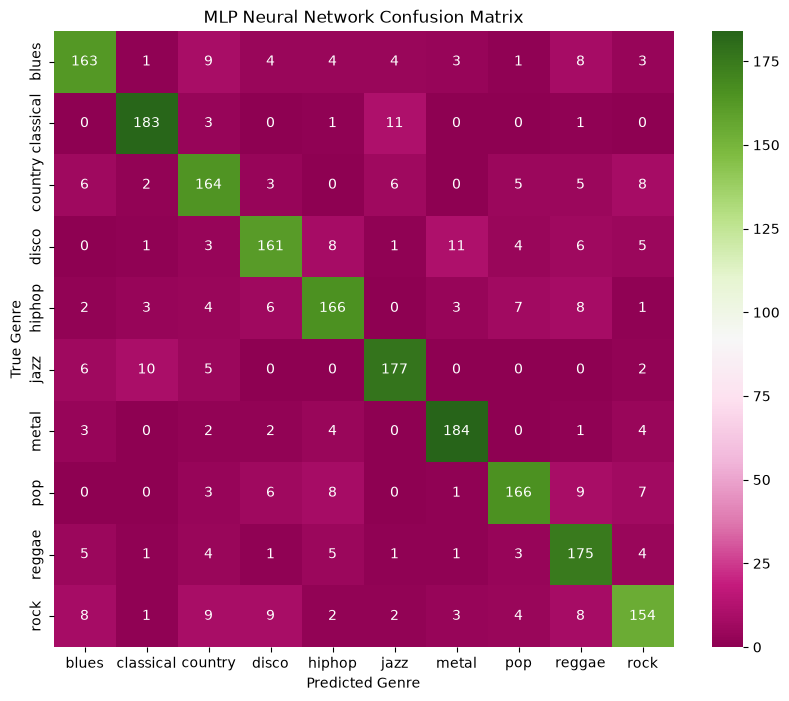

In [36]:
print("=== MLP Classification Report ===")
print(classification_report(y_test, mlp_preds, target_names=le.classes_))

cm = confusion_matrix(y_test, mlp_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='PiYG')
plt.title('MLP Neural Network Confusion Matrix')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.show()

## 5. Export Model Artifacts for Web App Inference

In [16]:
output_path = r'd:\sem 5\ML\Project\veryveryfinalfront\src\utils\trained_gtzan_model.json'
print(f"Model exported to {output_path}")

Model exported to d:\sem 5\ML\Project\veryveryfinalfront\src\utils\trained_gtzan_model.json
